# Simple Understanding of K-Means Clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('/home/Jatin/Downloads/student_clustering.csv')
df.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


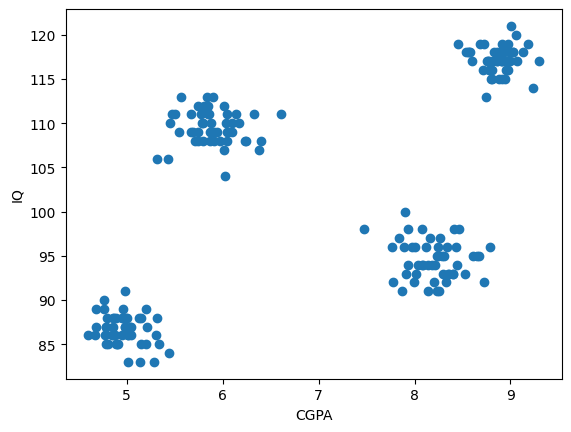

In [3]:
plt.xlabel("CGPA") and plt.ylabel("IQ")
plt.scatter(df['cgpa'], df['iq'])

## Identifing best "K" values for clustering

In [4]:
wcss = []
for i in range(1,11):
    k_c = KMeans(n_clusters=i)
    k_c.fit_predict(df)
    wcss.append(k_c.inertia_)       # extration k values

print(wcss)

[29957.898288, 4184.14127, 2503.3975810000006, 681.96966, 514.1616803171114, 427.96277698772144, 431.2778531741758, 306.3482310204082, 212.86319129587898, 195.7491260849436]


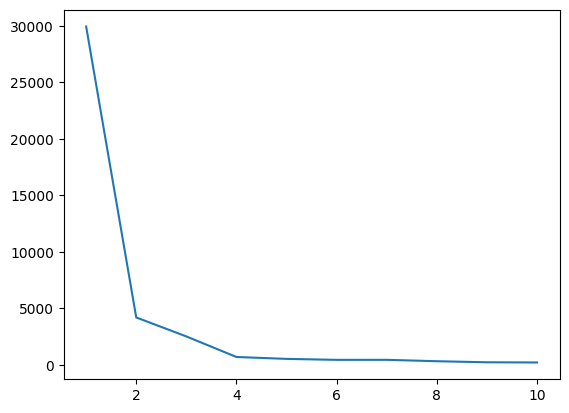

In [5]:
plt.plot(range(1,11),wcss)

- We are getting best clusters values i.e., 4

In [6]:
X = df.iloc[:,:].values     # assigining values (clusters) to - all rows, all columns 
km = KMeans(n_clusters=4)
y_mean = km.fit_predict(df)

In [7]:
y_mean

array([2, 3, 1, 1, 3, 3, 1, 0, 3, 1, 2, 3, 1, 2, 3, 1, 3, 1, 3, 3, 1, 2,
       1, 2, 2, 1, 2, 0, 1, 3, 0, 3, 0, 3, 1, 1, 0, 3, 2, 3, 2, 1, 1, 2,
       0, 0, 1, 3, 0, 3, 2, 2, 0, 1, 0, 3, 3, 0, 3, 0, 3, 1, 1, 0, 2, 0,
       1, 2, 3, 1, 3, 0, 1, 2, 3, 0, 3, 0, 2, 1, 1, 0, 3, 2, 0, 2, 0, 3,
       0, 3, 0, 0, 1, 2, 1, 1, 0, 1, 2, 0, 3, 2, 2, 0, 2, 2, 1, 2, 0, 0,
       1, 0, 3, 3, 1, 0, 1, 3, 0, 2, 2, 3, 1, 0, 1, 2, 1, 3, 2, 1, 1, 3,
       2, 2, 3, 0, 3, 2, 1, 1, 1, 2, 3, 2, 2, 0, 2, 0, 3, 2, 0, 2, 0, 0,
       2, 1, 3, 0, 3, 1, 2, 0, 3, 1, 0, 2, 3, 2, 2, 0, 0, 3, 0, 2, 2, 1,
       0, 3, 2, 0, 0, 3, 3, 3, 1, 2, 1, 1, 0, 3, 1, 1, 2, 2, 1, 2, 0, 3,
       3, 0], dtype=int32)

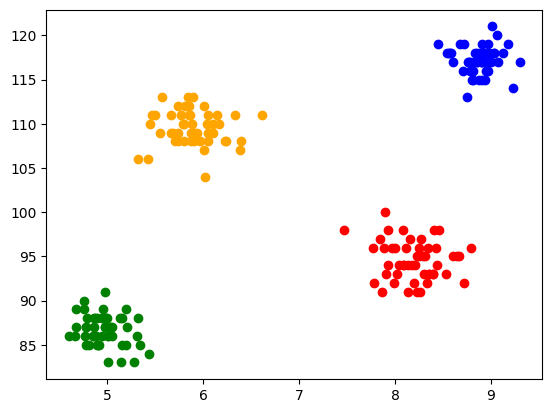

In [8]:
plt.scatter(X[y_mean == 0,0], X[y_mean == 0,1], color='blue')
plt.scatter(X[y_mean == 1,0], X[y_mean == 1,1], color='red')
plt.scatter(X[y_mean == 2,0], X[y_mean == 2,1], color='green')
plt.scatter(X[y_mean == 3,0], X[y_mean == 3,1], color='orange')

##### **Better representation through graph, representing student's IQ vs CGPA**

## 3D data implimentation 

In [9]:
from sklearn.datasets import make_blobs

In [10]:
# sample dummy data 

centroids = [(-5,-5,-5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

X, y = make_blobs(n_samples=200, cluster_std=cluster_std, centers=centroids, n_features=3, random_state=1)

In [11]:
X

array([[ 4.33424548,  3.32580419, -4.17497018],
       [-3.32246719,  3.22171129, -4.625342  ],
       [-6.07296862, -4.13459237, -7.3015387 ],
       [ 6.90465871,  6.1110567 , -4.3409502 ],
       [-2.60839207,  2.95015551, -2.2346649 ],
       [ 5.88490881,  4.12271848, -5.86778722],
       [-4.68484061, -4.15383935, -5.85951594],
       [-1.82542929,  3.96089238, -3.4075272 ],
       [-5.34385368, -4.95640314, -5.62000084],
       [ 4.91549197,  4.70263812, -4.582698  ],
       [-3.80108212, -4.81484358, -5.37528495],
       [ 4.6735005 ,  3.65732421, -3.88561702],
       [-6.23005814, -4.4494625 , -4.20719313],
       [-3.90232915,  2.95112294, -4.6949209 ],
       [ 3.72744124,  5.31354772, -4.49681519],
       [-3.3088472 ,  3.05743945, -3.81896126],
       [ 2.70273021, -2.21732429,  3.17390257],
       [ 4.06438286, -0.36217193,  3.214466  ],
       [ 4.69268607, -2.73794194,  5.15528789],
       [ 4.1210827 , -1.5438783 ,  3.29415949],
       [-6.61577235, -3.87858229, -4.591

In [12]:
import plotly.express as px

In [13]:
fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])
fig.show()

In [15]:
wcss = []
for i in range(1,21):
    k_c = KMeans(n_clusters=i)
    k_c.fit_predict(df)
    wcss.append(k_c.inertia_)

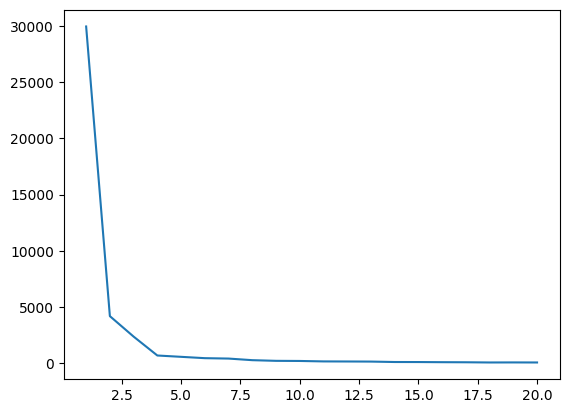

In [16]:
plt.plot(range(1,21), wcss)

In [17]:
km = KMeans(n_clusters=4)
y_pred = km.fit_predict(X)

In [18]:
df = pd.DataFrame()

In [20]:
df['col1'] = X[:,0]
df['col2'] = X[:,1]
df['col3'] = X[:,2]
df['label'] = y_pred

In [21]:
fig = px.scatter_3d(df, x='col1', y='col2', z='col3', color='label')
fig.show()